# 5. POŁĄCZENIA RESIDUALNE I TRANSFER LEARNING

## 0.Cel listy

Celem tej listy zadań jest zapoznanie się z:

* gotowymi architekturami sieci neuronowych,
* ideą **połączeń residualnych (skip connections)**,
* oraz praktycznym wykorzystaniem **transfer learningu** w zadaniach z zakresu wizji komputerowej.

W poprzednich listach budowaliśmy sieci neuronowe „od zera”, projektując architekturę warstwa po warstwie. W praktyce jednak **bardzo rzadko trenuje się modele od podstaw**- zamiast tego korzysta się z gotowych, sprawdzonych architektur i wag wytrenowanych na dużych zbiorach danych, dotrenowując model pod konretne zadanie.



W tej liście:

* skupimy się na architekturach z rodziny **ResNet**,
* zobaczymy, czym są i po co stosuje się połączenia residualne,
* porównamy różne strategie treningu:

  * inferencję na modelu pretrenowanym,
  * trenowanie tylko ostatniej warstwy,
  * fine-tuning całego modelu,
  * trening od zera.



Do wykonania zadania rekomendowane jest użycie zbioru **CIFAR** z torchvision z powodu, że jest to trudniejszy zbiór i powinno być na nim lepiej widać, różne schematy uczenia, ale jeśli będzie występowal problem z zasobami obliczeniowymi można wykonać zadanie na zbiorze **FashionMNIST**




## 1.Połączenia residualne- teoria

### Problem zanikającego i wybuchającego gradientu

Podczas trenowania sieci neuronowej używamy algorytmu **propagacji wstecznej (backpropagation)**, w którym gradient funkcji straty jest przekazywany od wyjścia sieci do jej początkowych warstw.

Dla bardzo głębokich sieci pojawiają się dwa poważne problemy:

###  Zanikający gradient (vanishing gradient)

* gradient w kolejnych warstwach staje się coraz mniejszy,
* pierwsze warstwy uczą się bardzo wolno lub wcale,
* sieć nie wykorzystuje swojej głębokości.

###  Wybuchający gradient (exploding gradient)

* gradient w kolejnych warstwach gwałtownie rośnie,
* prowadzi to do niestabilnego treningu,
* wagi mogą przyjmować bardzo duże wartości (NaN).

Oba problemy są szczególnie widoczne w **głębokich sieciach** (dziesiątki lub setki warstw).



## Skąd bierze się ten problem? (intuicyczna matematyka)

Rozważmy bardzo uproszczony przypadek sieci składającej się z wielu warstw:

$$
h_l = f(W_l h_{l-1})
$$


Podczas propagacji wstecznej gradient względem wcześniejszych warstw zawiera **iloczyn pochodnych**:

$$
\frac{\partial L}{\partial h_0}
$$

$$
\frac{\partial L}{\partial h_L}
\cdot
\prod_{l=1}^{L}
\frac{\partial h_l}{\partial h_{l-1}}
$$

Jeśli:

* pochodne są **mniejsze od 1** - iloczyn dąży do zera → *zanik gradientu*
* pochodne są **większe od 1** - iloczyn rośnie wykładniczo → *wybuch gradientu*

Nawet przy użyciu funkcji aktywacji takich jak ReLU oraz technik typu Batch Normalization, problem **nie znika całkowicie** dla bardzo głębokich sieci.

#### Dodatkowe materiały:
- [Vanishing AND Exploding Gradient Problem Explained](https://www.youtube.com/watch?v=CzNFuL_5uig)
- [kod + wizaulizacje problemu](https://www.geeksforgeeks.org/deep-learning/vanishing-and-exploding-gradients-problems-in-deep-learning/)




### Intuicja stojąca za połączeniem residualnym

Zastanówmy się nad prostym przypadkiem.

Załóżmy, że idealna transformacja pomiędzy wejściem a wyjściem pewnej części sieci to:
$$
H(x) = x
$$

Czyli: **warstwy nic nie zmieniają**.

Dla klasycznej sieci neuronowej oznacza to, że musi ona nauczyć się funkcji identyczności, co w praktyce **nie jest trywialne** dla wielu warstw nieliniowych.



Zamiast uczyć się funkcji:
$$
H(x)
$$

możemy uczyć się **residuum**:
$$
F(x) = H(x) - x
$$

Jeśli najlepszym rozwiązaniem jest identyczność, to:
$$
F(x) = 0
$$

Uczenie się „zera” lub „małej poprawki” jest:

* łatwiejsze,
* stabilniejsze,
* szybsze dla optymalizacji gradientowej.



### Wzór matematyczny połączenia residualnego

Połączenie residualne definiujemy jako:

$$
y = F(x) + x
$$

gdzie:

* x - wejście do bloku,
* F(x) - klasyczna transformacja (np. Conv -> ReLU -> Conv),
* y - wyjście bloku residualnego.

### Co to zmienia?

* gradient może przepływać **bezpośrednio** przez składnik (+x),
* nawet jeśli F(x) jest trudne do nauczenia,
* sieć zawsze ma „bezpieczną ścieżkę” dla propagacji gradientu.


## Najważniejsze konsekwencje połączeń residualnych

* umożliwiają trenowanie **bardzo głębokich sieci**,
* zmniejszają problem degradacji jakości,
* stabilizują propagację gradientu,
* sprawiają, że dodawanie kolejnych warstw **nie pogarsza wyników**.

Poniżej obrazek przedstawiający schemat działania tego połączenia.


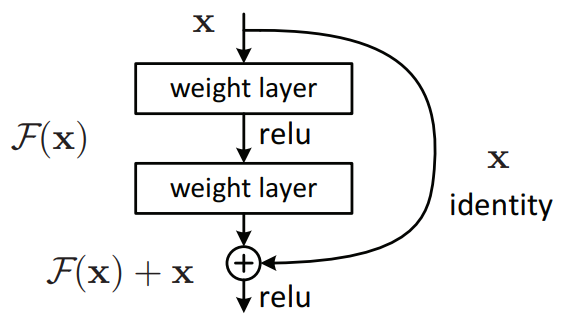

DODATKOWE MATERIAŁY:
- [ORGINALNY PAPER](https://arxiv.org/pdf/1512.03385) - Gorąco polecam, ponieważ autorzy bardzo klarownie postawili hipotezę, ekperyment weryfikujący, oraz wnioski. Jest to wzór pod względem tego jak publikacja powinna wyglądać.
- [ORGINALNY PAPER OMÓWIENIE NA YT](https://www.youtube.com/watch?v=GWt6Fu05voI)
- [SZCZEGÓŁOWE WYJAŚNIENIE](https://mbrenndoerfer.com/writing/residual-connections-deep-neural-networks-resnet)

## 2. ZADANIE 1. IMPLEMENTACJA MODUŁU RESIDUALNEGO
Jako zadanie rozgrzewkowe należy na podstawie schematu powyżej dokończyć implementację modułu residualnego, przepuścić przez niego "dummy input" i uruchomić testy w celu weryfikacji poprawności. Celem jest zobaczenie przykładowej implementacji takiego bloku.

**UWAGA**: Symbol "+" na schemacie odpowada zwykłemu **dodaniu tensorów** a nie konkatenacji.

In [1]:
#Dummy wejście (NIE NALEŻY MODYFIKOWAĆ KOMÓRKI)

import torch
# Ustalmy powtarzalność
torch.manual_seed(0)

# Dummy batch obrazów: (batch_size, channels, height, width)
B, C, H, W = 4, 16, 32, 32
x = torch.randn(B, C, H, W)
print("x shape:", x.shape)


x shape: torch.Size([4, 16, 32, 32])


In [2]:
# Moduł ResidualBlock z brakującym kodem (TODO)

import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    """
    Blok residualny zgodny ze schematem:
        x -> Conv -> ReLU -> Conv -> ( + x ) -> ReLU
    Zakładamy, że wejście i wyjście mają te same wymiary (C, H, W).
    """
    def __init__(self, channels: int, kernel_size: int = 3):
        super().__init__()
        padding = kernel_size // 2  # żeby zachować H,W dla kernel=3

        self.conv1 = nn.Conv2d(channels, channels, kernel_size=kernel_size, padding=padding, bias=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=kernel_size, padding=padding, bias=True)
        self.relu = nn.ReLU(inplace=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 1: F(x) = Conv -> ReLU -> Conv
        # 2: skip connection: out = F(x) + x
        # 3: ReLU na końcu i zwróć wynik

        # ----- START TODO -----
        fx = self.conv2(self.relu(self.conv1(x)))
        out = fx + x
        out = self.relu(out)
        return out
        # ----- END TODO -----


In [3]:
# Testy (NIE NALEŻY MODYFIKOWAĆ KOMÓRKI)

def zero_out_conv(conv: nn.Conv2d):
    with torch.no_grad():
        conv.weight.zero_()
        if conv.bias is not None:
            conv.bias.zero_()

# 1) Inicjalizacja i test wymiarów
block = ResidualBlock(channels=C)

y = block(x)
print("y shape:", y.shape)

assert y.shape == x.shape, f"Shape mismatch: got {y.shape}, expected {x.shape}"
print("Shape test passed")

# 2) Test semantyczny: jeśli ustawimy wagi obu conv na 0 -> F(x)=0
#    wtedy y = ReLU(x) (bo na końcu jest ReLU po dodaniu).
zero_out_conv(block.conv1)
zero_out_conv(block.conv2)

y2 = block(x)
expected = torch.relu(x)

max_diff = (y2 - expected).abs().max().item()
print("max |y2 - ReLU(x)| =", max_diff)

assert torch.allclose(y2, expected, atol=1e-6), "Residual behavior test failed"
print("Residual behavior test passed (F(x)=0 => y=ReLU(x))")

# 3) Test gradientu: sprawdzamy czy gradient przepływa do x
x_req = x.clone().detach().requires_grad_(True)
y3 = block(x_req)
loss = y3.sum()
loss.backward()

grad_norm = x_req.grad.norm().item()
print("x grad norm:", grad_norm)

assert grad_norm > 0, "Gradient flow test failed (grad_norm should be > 0)"
print("Gradient flow test passed")


y shape: torch.Size([4, 16, 32, 32])
Shape test passed
max |y2 - ReLU(x)| = 0.0
Residual behavior test passed (F(x)=0 => y=ReLU(x))
x grad norm: 180.78993225097656
Gradient flow test passed


## 3. PRETRENOWANE MODELE I TRANSFER LEARNING


#### Dlaczego nie zawsze trenujemy model od zera?

W zadaniach z zakresu wizji komputerowej obrazy- niezależnie od konkretnego problemu- mają **wspólną strukturę**.

W głębokich sieciach konwolucyjnych:

* **początkowe warstwy** uczą się bardzo ogólnych cech:

  * krawędzie,
  * narożniki,
  * proste tekstury,
* **środkowe warstwy** łączą je w bardziej złożone wzorce:

  * fragmenty obiektów,
  * charakterystyczne kształty,
* **końcowe warstwy** są najbardziej specyficzne dla zadania:

  * konkretne klasy,
  * decyzje klasyfikacyjne.

Oznacza to, że wiedza zdobyta przez model na jednym zadaniu (np. klasyfikacja milionów obrazów) może być **ponownie wykorzystana** w innym, podobnym zadaniu.

Dlatego w praktyce:

* **nie musimy uczyć modelu wszystkiego od zera**,
* możemy wykorzystać wcześniej wyuczone wagi,
* oszczędzamy czas, dane i zasoby obliczeniowe.


DODATKOWE MATERIAŁY:
- [Co "widzą" CNN-y w kolejnych warstwach](https://arxiv.org/pdf/1311.2901)


## Podstawowe pojęcia: pretraining i transfer learning

**Model pretrenowany (pretrained model)**

* jego wagi zostały wyuczone na dużym zbiorze danych,
* zwykle na **ogólnym zadaniu** (np. klasyfikacja obrazów w przypadku computer vision, chodź nie musi tak być),
* Często mówi się o takim modelu w naszym rozwiązaniu jako **Backbone**, ponieważ on odpowada za większość "wiedzy" w naszym modelu.

W przypadku wizji komputerowej bardzo często modele są pretrenowane na zbiorze ImageNet, który zawiera miliony obrazów i tysiące klas.

Przykład:
Resnet18 z biblioteki torchvision wraz z wagami z ImageNeta.



**Zamrażanie wag**
- Polega na tym że część lub całość modelu (wag) nie przekazuje gradientu dalej, co oznacza że te konretne wagi nie będą się dalej optymalizowały w trakcie trenigu
- W torchu odbywa się między innymi poprzez
  * `requires_grad = False`,
- Stosowane kiedy chcemy pozostawić wagi modelu i zmodyfikować tylko jego fragment (najczęściej ostatnią warstwę klasyfikujacą lub pare ostatnich warst)


**Transfer learning**
Polega na wykorzystaniu modelu pretrenowanego oraz dostosowaniu go do **zadania docelowego**.

Może to przyjmować różne formy, w zależności od ilości danych i podobieństwa zadań. Jest to szeroki temat, ale najkrócej tłumacząc strategie jakie są nabardziej znane to:
- **linear probing**- Zamrożenie całości modelu i wytrenowaniu jedynie ostatniej warstwy klasyfikującej pod nasze zadanie .
- **partial fine-tuning**Zamrożenie większości modelu, ale dotrenowujemy też ostatnie warstwy/blocki w naszym backbonie . Ile dokładnie odmrażamy a ile zostawiamy jest bardzo mocno zależne od naszego zadania, ilości danych  oraz doświadczenia.
- **Full fine-tuning** Odmrożenie całego modelu i dotrenowanie go w całości naszych danych


DODATKOWE MATERIAŁY:
- [linear probing vs finetuning](https://www.phontron.com/class/anlp2022/assets/slides/anlp-10-raghunathan.pdf)
- [how to freez model in torch](https://python.plainenglish.io/how-to-freeze-model-weights-in-pytorch-for-transfer-learning-step-by-step-tutorial-a533a58051ef)



## Architektura ResNet i modele dostępne w torchvision

**ResNet (Residual Network)** to rodzina głębokich sieci konwolucyjnych opartych na:

* blokach residualnych,
* połączeniach typu skip connection,
* bardzo dużej głębokości (dziesiątki lub setki warstw).

Kluczowa idea:

* sieć uczy się **residuum** zamiast pełnej transformacji,
* co umożliwia stabilny trening bardzo głębokich modeli.


Biblioteka `torchvision.models` udostępnia gotowe implementacje ResNetów, m.in.:

* `resnet18`
* `resnet34`
* `resnet50`
* `resnet101`
* `resnet152`

Różnią się one:

* liczbą warstw,
* liczbą parametrów,
* złożonością bloków residualnych.

Modele te:

* mogą być inicjalizowane losowo,
* lub z wagami **pretrenowanymi na ImageNet**.


DODATKOWE MATERIAŁY:
- [torchvision resnet18](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html)

## 4. ZADANIE 2- transfer learning



Celem zadania jest praktyczne zapoznanie się z różnymi strategiami wykorzystania **modeli pretrenowanych** na przykładzie architektury **ResNet** oraz porównanie ich zachowania podczas treningu.


### 1. Wybór i analiza architektury

1. Wybierz **jeden model z rodziny ResNet**:

   * `ResNet18` lub `ResNet34`
     (większe modele nie są wymagane do tego zadania).

2. Załaduj model **z wagami pretrenowanymi na ImageNet**.

3. Wyświetl architekturę modelu (`print(model)` lub podobnie) i:

   * zidentyfikuj część konwolucyjną (backbone),
   * zlokalizuj ostatnią warstwę klasyfikacyjną,
   * zwróć uwagę na strukturę bloków residualnych.

Celem tego punktu jest **zrozumienie, z jakich elementów składa się model**, a nie tylko jego użycie jako „czarnej skrzynki”.


### 2. Przygotowanie danych i wyjścia modelu

1. Wykorzystaj zbiór danych wskazany we wprowadzeniu (np. CIFAR / FashionMNIST).
2. Dostosuj dane wejściowe do wymagań modelu:

   * odpowiedni rozmiar obrazu,
   * liczba kanałów,
   * normalizacja.

3. Zastąp **ostatnią warstwę liniową** modelu tak, aby liczba neuronów wyjściowych odpowiadała liczbie klas w zadaniu docelowym.


### 3. Zestaw eksperymentów

Na tym samym zbiorze danych przeprowadź **następujące eksperymenty**, zachowując spójne ustawienia (batch size, optimizer, itp.).

- Eksperyment 1 - Linear probing

  * Zamroź wszystkie warstwy modelu poza ostatnią warstwą liniową.
  * Trenuj **tylko nową warstwę klasyfikacyjną**.
  * Model pełni rolę ekstraktora cech.


- Eksperyment 2 - Partial fine-tuning

  * Zamroź większość modelu,
  * Odmroź:

    * ostatni blok ResNeta,
    * oraz warstwę klasyfikacyjną.
  * Trenuj tylko te elementy.


- Eksperyment 3 - Full fine-tuning

  * Użyj modelu pretrenowanego,
  * Odmroź **wszystkie warstwy**,
  * Dotrenuj cały model na zadaniu docelowym.
  * Trening **nie musi być długi** - wystarczy kilka lub kilkanaście epok.


- Eksperyment 4 - Trening od zera

  * Załaduj ten sam model ResNet, ale **bez wag pretrenowanych**.
  * Wytrenuj go od zera na tym samym zbiorze danych.
  * Wystarczy kilka pierwszych epok - celem jest obserwacja przebiegu uczenia.


### UWAGI

* Stosuj dobre praktyki treningowe z poprzednich list.
* **Zawsze śledź `train loss` oraz `validation loss`** - w tym zadaniu jest to szczególnie istotne.
* Monitoruj metryki na zbiorze treningowym, walidacyjnym i testowym.
* Porównuj podejścia między sobą:

  * wartości strat,
  * metryki walidacyjne i testowe,
  * szybkość oraz stabilność zbieżności.
* Zwróć uwagę na różnice w przebiegu krzywych uczenia między ekperymentami.
* Przy full fine-tuningu i treningu od zera **wystarczy kilka / kilkanaście epok** - nie jest wymagane doprowadzenie treningu do pełnej konwergencji.
* Celem zadania jest **zrozumienie dynamiki uczenia i wpływu pretrenowania**, a nie maksymalizacja końcowej dokładności.
* Przy dotrenowywaniu, często stosuje się mniejszy lr niż przy treningu od zera.


In [ ]:
# TODO- WPISZ SWÓJ KOD